In [ ]:
#%pip install tensorflow

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# load and pre-trained VGG16
model = VGG16(weights='imagenet',include_top=True)

553467096/553467096 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [ ]:
img_path = "dog.png"
img = load_img(img_path, target_size=(224, 224))
img_batch = np.expand_dims(img_to_array(img), axis=0)
img_batch = preprocess_input(img_batch)

In [ ]:
predictions = preprocess_input(img_batch)

In [ ]:
predictions = model.predict(img_batch)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


In [ ]:
decoded = tf.keras.applications.vgg16.decode_predictions(predictions, top=3)[0]

In [ ]:
print(decoded)

[('n02106662', 'German_shepherd', np.float32(0.99445677)), ('n02105162', 'malinois', np.float32(0.0048057656)), ('n02091467', 'Norwegian_elkhound', np.float32(0.00048141484))]


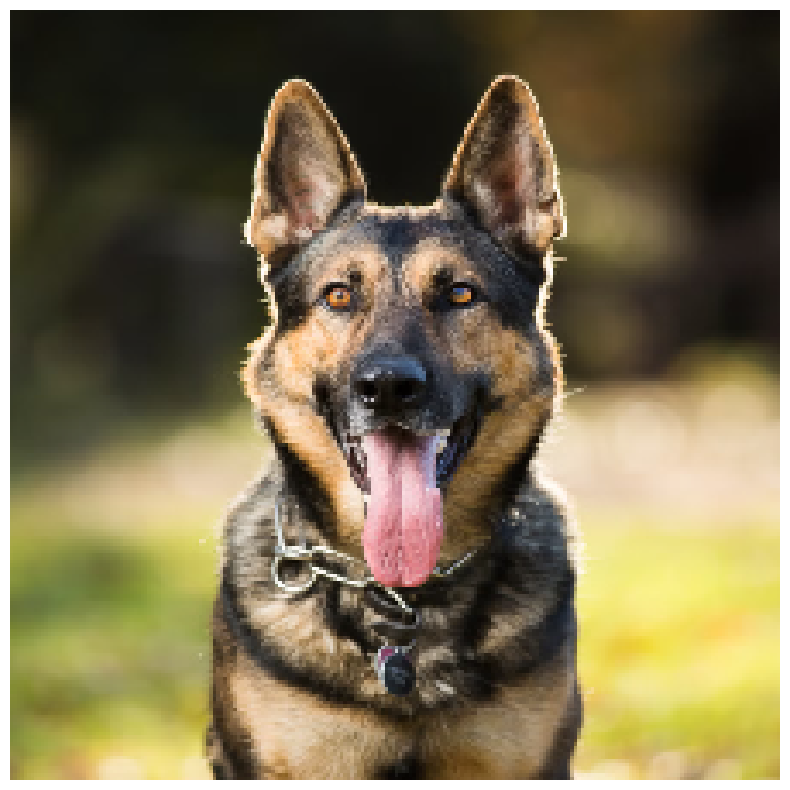

VGG16 Top 3 Predictions:
German_shepherd: 99.45%
malinois: 0.48%
Norwegian_elkhound: 0.05%


In [ ]:
# show result
plt.figure(figsize=(10,10))
plt.imshow(img)
plt.axis('off')
plt.show()
print("VGG16 Top 3 Predictions:")
for _, class_name, prob in decoded:
    print(f"{class_name}: {prob*100:.2f}%")